## Description

```
Bài toán của tôi là xác định xem tâm ảnh có nằm trong Object có category là Bia4_Inside. Tôi dùng classification với fastai.
```

## Setup

In [ ]:
# Cell 1: Install và import thư viện
%conda install fastai torch torchvision pycocotools scikit-learn cpuonly -q

In [1]:
%pip install datatorch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.9/96.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.9/140.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━

## Datatorch

In [2]:
import datatorch as dt
from google.colab import userdata

api = dt.api.ApiClient(userdata.get('DATATORCH_API_KEY'))

# For the default schema named 'All'
api.project('gierusalem/bia4').download('All-Coco')

100%|██████████| 100/100 [01:06<00:00,  1.51it/s]


## Utilities

In [2]:
def simple_predict_with_circle(trainer, img_path, circle_radius=10):
    """
    Phiên bản đơn giản: chỉ hiển thị ảnh với chấm tròn ở giữa
    """
    # Make prediction
    pred, pred_idx, probs = trainer.learn.predict(img_path)

    # Load image
    img = Image.open(img_path)
    img_array = np.array(img)

    # Create plot
    plt.figure(figsize=(10, 8))

    # Display image
    plt.imshow(img_array)

    # Get center coordinates
    height, width = img_array.shape[0], img_array.shape[1]
    center_x, center_y = width // 2, height // 2

    # Add circle at center
    circle = plt.Circle((center_x, center_y), circle_radius,
                       linewidth=3, edgecolor='red', facecolor='red', alpha=0.7)
    plt.gca().add_patch(circle)

    # Add crosshair
    plt.axhline(y=center_y, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=center_x, color='red', linestyle='--', alpha=0.5)

    # Add title and info
    plt.title(f'Prediction: {pred} | Confidence: {probs[pred_idx]:.4f}\n'
              f'Center: ({center_x}, {center_y}) | Size: {width}×{height}',
              fontsize=12, pad=20)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return pred, probs[pred_idx], (center_x, center_y)

def predict_multiple_images(trainer, img_paths, circle_radius=8):
    """
    Dự đoán và hiển thị nhiều ảnh cùng lúc
    """
    n_images = len(img_paths)
    fig, axes = plt.subplots(1, n_images, figsize=(5*n_images, 4))

    if n_images == 1:
        axes = [axes]

    for i, img_path in enumerate(img_paths):
        # Make prediction
        pred, pred_idx, probs = trainer.learn.predict(img_path)

        # Load image
        img = Image.open(img_path)
        img_array = np.array(img)

        # Display image
        axes[i].imshow(img_array)

        # Get center coordinates
        height, width = img_array.shape[0], img_array.shape[1]
        center_x, center_y = width // 2, height // 2

        # Add circle at center
        circle = patches.Circle((center_x, center_y), circle_radius,
                               linewidth=2, edgecolor='red', facecolor='red', alpha=0.7)
        axes[i].add_patch(circle)

        # Add title
        axes[i].set_title(f'{pred}\n{probs[pred_idx]:.3f}', fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## Classification

In [ ]:
from fastai.vision.all import *

### sample

In [ ]:
set_seed(42, reproducible=True)
path = untar_data(URLs.PETS)/'images'
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2,
    label_func=lambda x: x[0].isupper(), item_tfms=Resize(224))

In [ ]:
learn = vision_learner(dls, resnet18, pretrained=True, metrics=error_rate)
learn.fine_tune(3)

In [ ]:
img = PILImage.create(path/'Abyssinian_109.jpg')
print(f"Probability it's a cat: {learn.predict(img)[2][1].item():.6f}")

### Bia4 Dataset

In [3]:
"""
BIA4 Image Classification Pipeline
Refactored version with functional programming principles and clean code practices
"""

import json
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from shapely.geometry import Point

# FastAI imports
from fastai.vision.all import *
from fastai.data.transforms import RandomSplitter

# os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'


# Configuration
class Config:
    """Configuration class for all paths and parameters"""
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    VALID_PCT = 0.2

    # Paths (using absolute paths)
    BASE_DIR = Path('/content').resolve()
    COCO_JSON_PATH = str(BASE_DIR / 'All-Coco-3.json')
    AUGMENTED_DIR = str(BASE_DIR / 'augmented')
    AUGMENTED_JSON_PATH = str(BASE_DIR / 'augmented' / 'augmented_coco.json')
    MERGED_JSON_PATH = str(BASE_DIR / 'All-Coco-3-merged.json')
    MODEL_SAVE_PATH = str(BASE_DIR / 'models' / 'bia4_inside_model.pkl')

    # Category ID for Bia4_Inside
    BIA4_INSIDE_CATEGORY_ID = 3

# Set random seeds for reproducibility
def set_random_seeds(seed: int = Config.SEED) -> None:
    """Set random seeds for reproducibility"""
    set_seed(seed, reproducible=True)
    torch.manual_seed(seed)
    np.random.seed(seed)

class CocoDataProcessor:
    """Processor for COCO format dataset operations"""

    def __init__(self, config: Config):
        self.config = config
        self.coco_data = None
        self.base_image_dir = None

    def load_coco_data(self, json_path: str, base_image_dir: str = None) -> Dict[str, Any]:
        """Load COCO JSON data with flexible image path"""
        self.base_image_dir = Path(base_image_dir).resolve() if base_image_dir else Path(json_path).parent.resolve()
        with open(json_path, 'r') as f:
            return json.load(f)

    def save_coco_data(self, data: Dict[str, Any], output_path: str) -> None:
        """Save COCO JSON data"""
        os.makedirs(Path(output_path).parent, exist_ok=True)
        with open(output_path, 'w') as f:
            json.dump(data, f, indent=2)

    def point_in_bbox(self, point: Tuple[float, float], bbox: List[float]) -> bool:
        """Check if a point is inside a bounding box"""
        x, y = point
        x_min, y_min, width, height = bbox
        return (x_min <= x <= x_min + width and
                y_min <= y <= y_min + height)

    def get_image_center(self, image_info: Dict) -> Tuple[float, float]:
        """Get center point of an image"""
        return (image_info['width'] / 2, image_info['height'] / 2)

class Bia4DatasetBuilder:
    """Builder for BIA4 classification dataset"""

    def __init__(self, processor: CocoDataProcessor):
        self.processor = processor
        self.config = processor.config
        self._annotations_by_image = None
        self._bia4_annotations_by_image = None

    @property
    def base_image_dir(self) -> Path:
        """Get base image directory from processor or config"""
        if hasattr(self.processor, 'base_image_dir') and self.processor.base_image_dir:
            return Path(self.processor.base_image_dir).resolve()
        return Path(self.config.COCO_JSON_PATH).parent.resolve()

    def _build_annotations_index(self, annotations: List[Dict]) -> Tuple[Dict, Dict]:
        """Build optimized indexes for faster lookup"""
        annotations_by_image = {}
        bia4_annotations_by_image = {}

        for ann in annotations:
            image_id = ann['image_id']

            # Index for all annotations
            if image_id not in annotations_by_image:
                annotations_by_image[image_id] = []
            annotations_by_image[image_id].append(ann)

            # Special index only for Bia4_Inside annotations
            if ann['category_id'] == self.config.BIA4_INSIDE_CATEGORY_ID:
                if image_id not in bia4_annotations_by_image:
                    bia4_annotations_by_image[image_id] = []
                bia4_annotations_by_image[image_id].append(ann)

        return annotations_by_image, bia4_annotations_by_image

    def _is_bia4_inside_center(self,
                             image_id: int,
                             center_point: Tuple[float, float],
                             annotations: List[Dict]) -> bool:
        """Ultra-optimized version with specialized indexing"""
        if self._annotations_by_image is None or self._bia4_annotations_by_image is None:
            self._annotations_by_image, self._bia4_annotations_by_image = \
                self._build_annotations_index(annotations)

        if image_id not in self._bia4_annotations_by_image:
            return False

        bia4_annotations = self._bia4_annotations_by_image[image_id]
        return any(
            self.processor.point_in_bbox(center_point, ann['bbox'])
            for ann in bia4_annotations
        )

    def create_label_dataframe(self, coco_data: Dict[str, Any]) -> pd.DataFrame:
        """Create DataFrame with image paths and labels"""
        data = []

        self._build_annotations_index(coco_data['annotations'])

        for img in coco_data['images']:
            img_id = img['id']
            img_path = self.base_image_dir / img['file_name']
            img_center = self.processor.get_image_center(img)

            label = self._is_bia4_inside_center(img_id, img_center, coco_data['annotations'])
            data.append([str(img_path), label])

        return pd.DataFrame(data, columns=['image_path', 'label'])

class Bia4Augmenter:
    """Data augmenter for BIA4 dataset using geometric transformations"""

    def __init__(self, processor: CocoDataProcessor):
        self.processor = processor
        self.config = processor.config

    @property
    def base_image_dir(self) -> Path:
        """Get base image directory from processor or config"""
        if hasattr(self.processor, 'base_image_dir') and self.processor.base_image_dir:
            return Path(self.processor.base_image_dir).resolve()
        return Path(self.config.COCO_JSON_PATH).parent.resolve()

    @property
    def augmented_dir(self) -> Path:
        """Get augmented directory path"""
        return Path(self.config.AUGMENTED_DIR).resolve()

    def create_mask(self, width: int, height: int, segmentation: List[float]) -> np.ndarray:
        """Create binary mask from segmentation points"""
        mask = Image.new('L', (width, height), 0)
        draw = ImageDraw.Draw(mask)

        poly_points = [(segmentation[i], segmentation[i+1])
                      for i in range(0, len(segmentation), 2)]

        if len(poly_points) < 3:
            return np.zeros((height, width), dtype=np.uint8)

        draw.polygon(poly_points, fill=255)
        return np.array(mask)

    def augment_dataset(self, coco_data: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
        """Perform center-based augmentation on the dataset"""
        augmented_data = []
        aug_json = {
            "info": coco_data['info'],
            "categories": coco_data['categories'],
            "images": [],
            "annotations": []
        }

        self.augmented_dir.mkdir(parents=True, exist_ok=True)

        max_img_id = max(img['id'] for img in coco_data['images'])
        max_ann_id = max(ann['id'] for ann in coco_data['annotations'])

        for img in coco_data['images']:
            augmentation_result = self._augment_single_image(
                img, coco_data['annotations'], max_img_id, max_ann_id)

            if augmentation_result:
                aug_img, aug_ann, new_img_id, new_ann_id = augmentation_result
                full_aug_path = self.augmented_dir / aug_img['file_name']
                augmented_data.append([str(full_aug_path), True])
                aug_json['images'].append(aug_img)
                aug_json['annotations'].append(aug_ann)

                max_img_id = new_img_id
                max_ann_id = new_ann_id

        return pd.DataFrame(augmented_data, columns=['image_path', 'label']), aug_json

    def _augment_single_image(self,
                            img: Dict,
                            annotations: List[Dict],
                            max_img_id: int,
                            max_ann_id: int) -> Optional[Tuple]:
        """Augment a single image by centering the Bia4_Inside region"""
        img_id = img['id']
        img_path = self.base_image_dir / img['file_name']
        img_center = self.processor.get_image_center(img)

        bia4_annotation = self._find_bia4_annotation(img_id, annotations)

        if not bia4_annotation or self.processor.point_in_bbox(img_center, bia4_annotation['bbox']):
            return None

        augmented_image = self._center_region(img, str(img_path), bia4_annotation, img_center)
        if augmented_image is None:
            return None

        new_img_id = max_img_id + 1
        new_ann_id = max_ann_id + 1

        aug_img, aug_ann = self._create_augmented_entries(
            img, bia4_annotation, augmented_image, new_img_id, new_ann_id)

        return aug_img, aug_ann, new_img_id, new_ann_id

    def _find_bia4_annotation(self, image_id: int, annotations: List[Dict]) -> Optional[Dict]:
        """Find Bia4_Inside annotation for given image"""
        for ann in annotations:
            if (ann['image_id'] == image_id and
                ann['category_id'] == self.config.BIA4_INSIDE_CATEGORY_ID):
                return ann
        return None

    def _center_region(self,
                      img_info: Dict,
                      img_path: str,
                      annotation: Dict,
                      center_point: Tuple[float, float]) -> Optional[Image.Image]:
        """Center the annotated region in the image"""
        try:
            original_img = Image.open(img_path).convert('RGB')
            np_img = np.array(original_img)

            mask = self.create_mask(img_info['width'], img_info['height'],
                                  annotation['segmentation'][0])
            if np.sum(mask) == 0:
                return None

            processed_img = self._reposition_region(np_img, mask, annotation, center_point)
            return Image.fromarray(processed_img)

        except Exception as e:
            print(f"Error processing image {img_path}: {e}")
            return None

    def _reposition_region(self,
                          image: np.ndarray,
                          mask: np.ndarray,
                          annotation: Dict,
                          center: Tuple[float, float]) -> np.ndarray:
        """Reposition the masked region to center"""
        x_min, y_min, w, h = annotation['bbox']
        seg_h, seg_w = int(h), int(w)

        new_x = max(0, min(int(center[0] - seg_w / 2), image.shape[1] - seg_w))
        new_y = max(0, min(int(center[1] - seg_h / 2), image.shape[0] - seg_h))

        cut_region = np.zeros_like(image)
        for c in range(3):
            cut_region[:,:,c] = image[:,:,c] * (mask // 255)

        result_image = image.copy()
        for c in range(3):
            result_image[:,:,c][mask > 0] = np.mean(result_image[:,:,c])

        paste_mask = np.roll(np.roll(mask, new_y - int(y_min), axis=0),
                           new_x - int(x_min), axis=1)

        for c in range(3):
            shifted_cut = np.roll(np.roll(cut_region[:,:,c],
                                        new_y - int(y_min), axis=0),
                                new_x - int(x_min), axis=1)
            result_image[:,:,c][paste_mask > 0] = shifted_cut[paste_mask > 0]

        return result_image

    def _create_augmented_entries(self,
                                original_img: Dict,
                                original_ann: Dict,
                                augmented_image: Image.Image,
                                new_img_id: int,
                                new_ann_id: int) -> Tuple[Dict, Dict]:
        """Create COCO entries for augmented image"""
        from uuid import uuid4

        aug_filename = f"aug_{original_img['file_name']}"
        aug_path = self.augmented_dir / aug_filename
        augmented_image.save(aug_path)

        new_img = {
            "id": new_img_id,
            "datatorch_id": str(uuid4()),
            "storage_id": str(uuid4()),
            "path": aug_filename,
            "width": original_img['width'],
            "height": original_img['height'],
            "file_name": aug_filename,
            "metadata": {},
            "date_captured": original_img['date_captured']
        }

        x_min, y_min, w, h = original_ann['bbox']
        img_center = self.processor.get_image_center(original_img)
        new_x = max(0, min(int(img_center[0] - w / 2), original_img['width'] - w))
        new_y = max(0, min(int(img_center[1] - h / 2), original_img['height'] - h))

        segmentation = original_ann['segmentation'][0]
        new_seg = [x + (new_x - x_min) for x in segmentation[::2]] + \
                 [y + (new_y - y_min) for y in segmentation[1::2]]

        new_ann = {
            "id": new_ann_id,
            "datatorch_id": str(uuid4()),
            "image_id": new_img_id,
            "category_id": self.config.BIA4_INSIDE_CATEGORY_ID,
            "segmentation": [new_seg],
            "area": original_ann['area'],
            "bbox": [new_x, new_y, w, h],
            "iscrowd": 0,
            "metadata": {}
        }

        return new_img, new_ann

class DatasetAnalyzer:
    """Analyzer for dataset statistics and visualization"""

    def __init__(self, processor: CocoDataProcessor, display_mode: str = "auto"):
        self.processor = processor
        self.display_mode = self._detect_display_mode(display_mode)

    def _detect_display_mode(self, mode: str) -> str:
        """Detect execution environment"""
        if mode != "auto":
            return mode

        try:
            from IPython import get_ipython
            if get_ipython() is not None:
                return "notebook"
        except:
            pass

        import matplotlib
        if matplotlib.get_backend().lower() not in ['agg', 'template']:
            return "notebook"

        return "console"

    def analyze_dataset(self, coco_data: Dict[str, Any]) -> None:
        """Print comprehensive dataset statistics"""
        categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
        bia4_count = sum(1 for ann in coco_data['annotations']
                        if ann['category_id'] == self.processor.config.BIA4_INSIDE_CATEGORY_ID)

        print("=== Dataset Analysis ===")
        print(f"Images: {len(coco_data['images'])}")
        print(f"Annotations: {len(coco_data['annotations'])}")
        print(f"Bia4_Inside annotations: {bia4_count}")
        print(f"Categories: {categories}")

        widths = [img['width'] for img in coco_data['images']]
        heights = [img['height'] for img in coco_data['images']]
        print(f"Image size range: {min(widths)}-{max(widths)} x {min(heights)}-{max(heights)}")

        self._detailed_analysis(coco_data)

    def _detailed_analysis(self, coco_data: Dict[str, Any]) -> None:
        """Detailed dataset analysis"""
        category_counts = {}
        for ann in coco_data['annotations']:
            cat_id = ann['category_id']
            category_counts[cat_id] = category_counts.get(cat_id, 0) + 1

        print("\n=== Category Distribution ===")
        for cat in coco_data['categories']:
            count = category_counts.get(cat['id'], 0)
            print(f"{cat['name']}: {count} annotations")

    def plot_label_distribution(self, df: pd.DataFrame, show_plot: bool = True) -> None:
        """Plot distribution of labels"""
        label_counts = df['label'].value_counts()

        if self.display_mode == "console":
            self._plot_console(label_counts)
        else:
            self._plot_notebook(label_counts, show_plot)

    def _plot_console(self, label_counts: pd.Series) -> None:
        """Display text-based plot in console"""
        print("\n=== Label Distribution ===")
        print(f"Bia4_Inside (True): {label_counts.get(True, 0)} images")
        print(f"Not Bia4_Inside (False): {label_counts.get(False, 0)} images")
        print(f"Ratio: {label_counts.get(True, 0) / len(label_counts):.2%}")

        total = label_counts.sum()
        true_count = label_counts.get(True, 0)
        false_count = label_counts.get(False, 0)

        print("\nASCII Chart:")
        true_bars = "█" * int(true_count / total * 50)
        false_bars = "█" * int(false_count / total * 50)
        print(f"True:  {true_bars} ({true_count})")
        print(f"False: {false_bars} ({false_count})")

    def _plot_notebook(self, label_counts: pd.Series, show_plot: bool = True) -> None:
        """Display matplotlib plot in notebook"""
        plt.figure(figsize=(8, 5))

        plt.subplot(1, 2, 1)
        label_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
        plt.title('Bia4_Inside Label Distribution')
        plt.xlabel('Label')
        plt.ylabel('Count')
        plt.xticks([0, 1], ['Not Bia4_Inside', 'Bia4_Inside'], rotation=45)

        plt.subplot(1, 2, 2)
        plt.pie(label_counts.values, labels=label_counts.index,
                autopct='%1.1f%%', colors=['#1f77b4', '#ff7f0e'])
        plt.title('Label Proportion')

        plt.tight_layout()
        if show_plot:
            plt.show()
        else:
            return plt.gcf()

    def plot_image_size_distribution(self, coco_data: Dict[str, Any]) -> None:
        """Image size distribution"""
        widths = [img['width'] for img in coco_data['images']]
        heights = [img['height'] for img in coco_data['images']]

        if self.display_mode == "console":
            print(f"\n=== Image Size Distribution ===")
            print(f"Width: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.1f}")
            print(f"Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.1f}")
        else:
            plt.figure(figsize=(10, 4))

            plt.subplot(1, 2, 1)
            plt.hist(widths, bins=20, alpha=0.7, color='skyblue')
            plt.title('Image Width Distribution')
            plt.xlabel('Width (pixels)')
            plt.ylabel('Frequency')

            plt.subplot(1, 2, 2)
            plt.hist(heights, bins=20, alpha=0.7, color='lightcoral')
            plt.title('Image Height Distribution')
            plt.xlabel('Height (pixels)')

            plt.tight_layout()
            plt.show()

    def generate_report(self, coco_data: Dict[str, Any], df: pd.DataFrame) -> Dict[str, Any]:
        """Generate detailed report dictionary"""
        report = {
            "summary": {
                "total_images": len(coco_data['images']),
                "total_annotations": len(coco_data['annotations']),
                "bia4_inside_annotations": sum(1 for ann in coco_data['annotations']
                                             if ann['category_id'] == self.processor.config.BIA4_INSIDE_CATEGORY_ID)
            },
            "label_distribution": {
                "bia4_inside": int(df['label'].sum()),
                "not_bia4_inside": int(len(df) - df['label'].sum()),
                "ratio": float(df['label'].mean())
            },
            "image_sizes": {
                "widths": [img['width'] for img in coco_data['images']],
                "heights": [img['height'] for img in coco_data['images']]
            }
        }
        return report

class Bia4ModelTrainer:
    """Trainer for BIA4 classification model"""

    def __init__(self, config: Config):
        self.config = config
        self.learn = None

    def create_data_loaders(self, df: pd.DataFrame) -> DataLoaders:
        """Create FastAI DataLoaders from DataFrame"""
        batch_tfms = aug_transforms(mult=1.5, max_rotate=15, max_zoom=1.1, max_warp=0.1)

        dblock = DataBlock(
            blocks=(ImageBlock, CategoryBlock),
            get_x=ColReader('image_path'),
            get_y=ColReader('label'),
            splitter=RandomSplitter(valid_pct=self.config.VALID_PCT, seed=self.config.SEED),
            item_tfms=Resize(self.config.IMG_SIZE),
            batch_tfms=batch_tfms
        )

        return dblock.dataloaders(df, bs=self.config.BATCH_SIZE)

    def create_learner(self, dls: DataLoaders, arch: callable = resnet50) -> None:
        """Create vision learner with specified architecture"""
        self.learn = vision_learner(
            dls,
            arch,
            pretrained=True,
            metrics=[accuracy, error_rate]
        )

    def find_optimal_lr(self) -> float:
        """Find optimal learning rate"""
        if self.learn is None:
            raise ValueError("Learner not initialized. Call create_learner first.")

        lr_min = self.learn.lr_find()
        plt.show()
        return lr_min.valley

    def train(self, epochs: int, base_lr: Optional[float] = None) -> None:
        """Train the model"""
        if self.learn is None:
            raise ValueError("Learner not initialized.")

        if base_lr is None:
            base_lr = self.find_optimal_lr()

        self.learn.fine_tune(epochs, base_lr=base_lr)

    def evaluate(self) -> Tuple[float, float, float]:
        """Evaluate model performance"""
        if self.learn is None:
            raise ValueError("Learner not initialized.")

        return self.learn.validate()

    def save_model(self, path: Optional[str] = None) -> None:
        """Save trained model"""
        if path is None:
            path = self.config.MODEL_SAVE_PATH

        self.learn.export(path)
        print(f"Model saved to {path}")

    def load_model(self, path: Optional[str] = None) -> None:
        """Load trained model"""
        if path is None:
            path = self.config.MODEL_SAVE_PATH

        self.learn = load_learner(path)
        print(f"Model loaded from {path}")



In [4]:
def predict_single_image(model_path: str, image_path: str) -> Tuple[str, float]:
    """Make prediction on a single image"""
    learn = load_learner(model_path)
    pred, pred_idx, probs = learn.predict(image_path)
    return pred, probs[pred_idx].item()

def batch_predict(model_path: str, image_paths: List[str]) -> List[Tuple[str, float]]:
    """Make predictions on a batch of images"""
    learn = load_learner(model_path)
    test_dl = learn.dls.test_dl(image_paths)
    preds, _ = learn.get_preds(dl=test_dl)

    results = []
    for pred in preds:
        pred_label = learn.dls.vocab[pred.argmax()]
        confidence = pred.max().item()
        results.append((pred_label, confidence))

    return results

Loading COCO data...
Creating base dataset...
=== Dataset Analysis ===
Images: 100
Annotations: 293
Bia4_Inside annotations: 100
Categories: {1: 'Bia4_Outside', 2: 'ChanBia', 3: 'Bia4_Inside'}
Image size range: 640-640 x 480-480

=== Category Distribution ===
Bia4_Outside: 100 annotations
ChanBia: 93 annotations
Bia4_Inside: 100 annotations


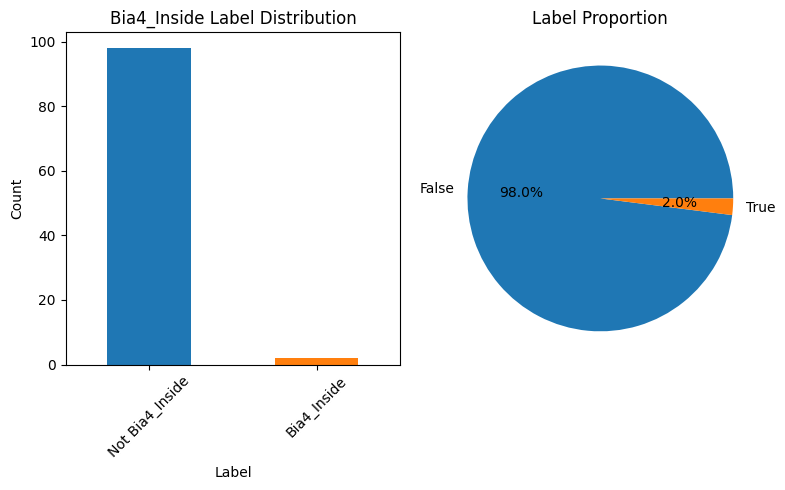

Handling augmented dataset...
Loading existing augmented data...
Combined dataset size: 197


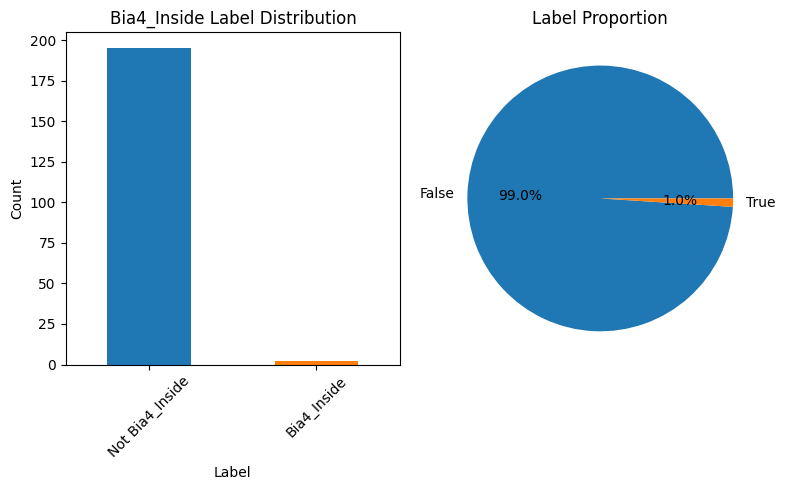

Creating data loaders...


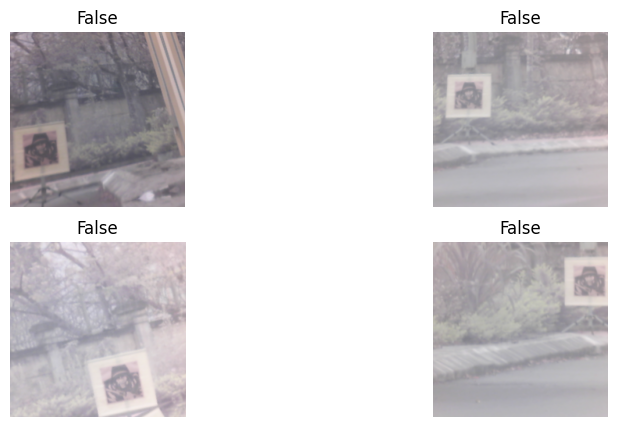

In [4]:
config = Config()
set_random_seeds(config.SEED)

processor = CocoDataProcessor(config)
dataset_builder = Bia4DatasetBuilder(processor)
augmenter = Bia4Augmenter(processor)
analyzer = DatasetAnalyzer(processor, display_mode='notebook')
trainer = Bia4ModelTrainer(config)

print("Loading COCO data...")
coco_data = processor.load_coco_data(config.COCO_JSON_PATH, config.BASE_DIR)

print("Creating base dataset...")
df_base = dataset_builder.create_label_dataframe(coco_data)
analyzer.analyze_dataset(coco_data)
analyzer.plot_label_distribution(df_base)

print("Handling augmented dataset...")
aug_json_path = Path(config.AUGMENTED_JSON_PATH)
if aug_json_path.exists():
    print("Loading existing augmented data...")
    aug_data = processor.load_coco_data(str(aug_json_path), base_image_dir=str(config.AUGMENTED_DIR))
    df_aug = dataset_builder.create_label_dataframe(aug_data)
    aug_json = aug_data
else:
    print("Performing data augmentation...")
    df_aug, aug_json = augmenter.augment_dataset(coco_data)
    processor.save_coco_data(aug_json, config.AUGMENTED_JSON_PATH)

merged_coco = coco_data.copy()
merged_coco['images'].extend(aug_json['images'])
merged_coco['annotations'].extend(aug_json['annotations'])
processor.save_coco_data(merged_coco, config.MERGED_JSON_PATH)

df_combined = pd.concat([df_base, df_aug], ignore_index=True)
print(f"Combined dataset size: {len(df_combined)}")
analyzer.plot_label_distribution(df_combined)

print("Creating data loaders...")
dls = trainer.create_data_loaders(df_combined)
dls.show_batch(max_n=4, figsize=(10, 5))


In [5]:
print("Initializing model...")
trainer.create_learner(dls, resnet50)

Initializing model...


In [8]:
print("First training round...")
trainer.train(epochs=4, base_lr=1e-3)


First training round...


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.122058,0.845527,0.717949,0.282051,01:21


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.893964,0.538453,0.717949,0.282051,01:42
1,0.814501,0.391362,0.846154,0.153846,01:39
2,0.672399,0.249904,0.923077,0.076923,01:40
3,0.590063,0.208048,0.948718,0.051282,01:42


Validation - Loss: 0.2080, Accuracy: 0.9487, Error Rate: 0.05128205195069313


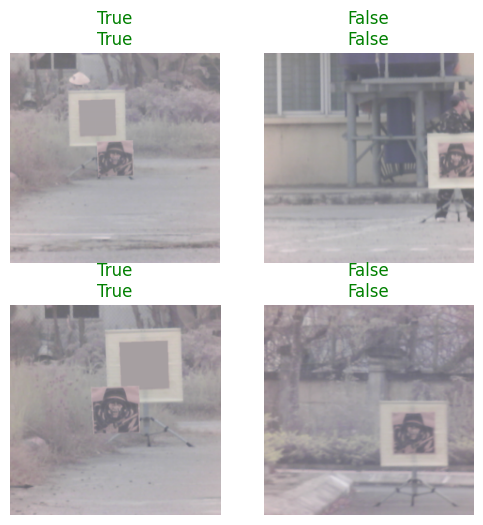

In [9]:
val_loss, val_accuracy, val_error = trainer.evaluate()
print(f"Validation - Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}, Error Rate: {val_error}")

trainer.learn.show_results(max_n=4)

Second training round...


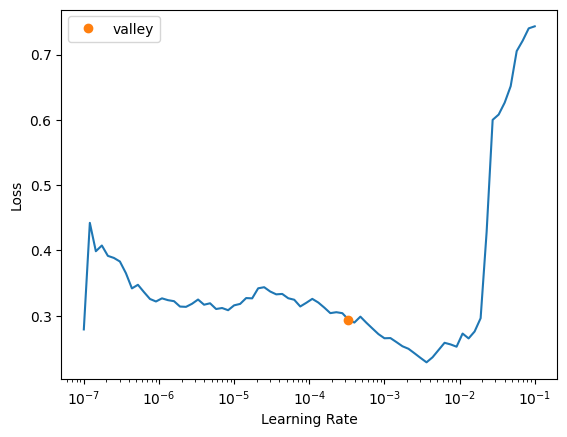

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.330159,0.220088,0.923077,0.076923,01:19


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.302446,0.227717,0.923077,0.076923,01:45
1,0.287294,0.231566,0.923077,0.076923,01:43
2,0.261386,0.169133,0.948718,0.051282,01:43
3,0.252503,0.161273,0.948718,0.051282,01:46
4,0.274999,0.228310,0.846154,0.153846,01:42
5,0.268771,0.228536,0.846154,0.153846,01:48
6,0.248311,0.229690,0.871795,0.128205,01:43
7,0.232383,0.246184,0.871795,0.128205,01:41


In [10]:
print("Second training round...")
trainer.train(epochs=8)

Validation - Loss: 0.2462, Accuracy: 0.8718, Error Rate: 0.12820513546466827


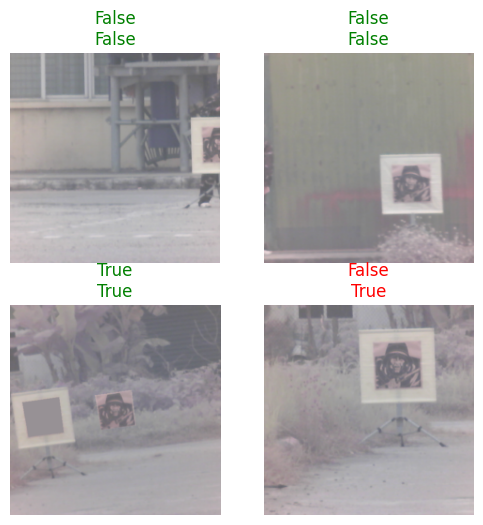

In [11]:
val_loss, val_accuracy, val_error = trainer.evaluate()
print(f"Validation - Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}, Error Rate: {val_error}")

trainer.learn.show_results(max_n=4)

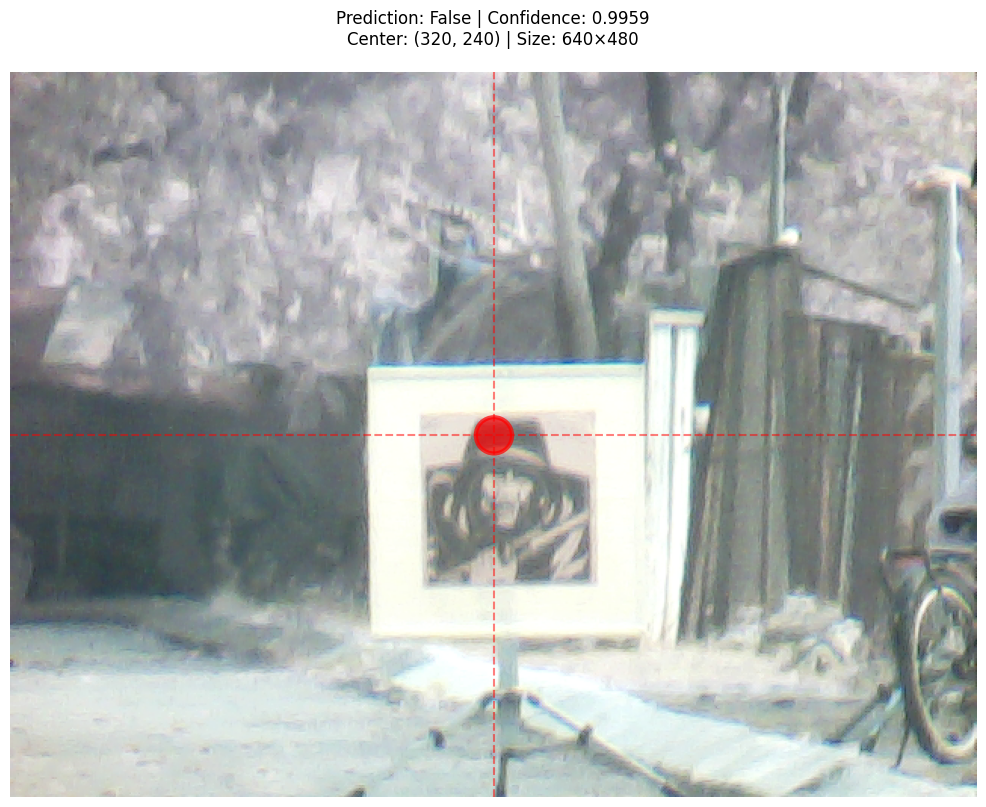

In [13]:
# Sử dụng phiên bản đơn giản
img_path = '/content/bia4 (734).bmp'
pred, confidence, center = simple_predict_with_circle(trainer, img_path, circle_radius=12)

### Tunning

TODO:
Hyperparameter Tuning:

Use learn.lr_find() for optimal learning rate.
Apply discriminative learning rates (lower for base, higher for head) with fit_one_cycle.
Tune batch size (e.g., 32-128) and weight decay (1e-4 to 1e-2).
Employ Bayesian optimization for params like epochs, dropout.

Model Architecture:

Switch to resnet50 or resnet101 for deeper features.
Try vision transformers via timm (e.g., vit_base_patch16_224).
Use efficientnet_b0 or higher for efficiency.
Ensemble multiple models (e.g., resnet + vit).

#### Apply discriminative learning rates (lower for base, higher for head) with fit_one_cycle

In [14]:
class Bia4ModelTrainer:
    """Trainer for BIA4 classification model with discriminative learning rates"""

    def __init__(self, config: Config):
        self.config = config
        self.learn = None
        self.dls = None
        self.training_history = []

    def create_data_loaders(self, df: pd.DataFrame) -> DataLoaders:
        """Create FastAI DataLoaders from DataFrame"""
        required_cols = ['image_path', 'label']
        if not all(col in df.columns for col in required_cols):
            raise ValueError(f"DataFrame must contain columns: {required_cols}")

        batch_tfms = aug_transforms(
            mult=1.5,
            max_rotate=15,
            max_zoom=1.1,
            max_warp=0.1
        )

        dblock = DataBlock(
            blocks=(ImageBlock, CategoryBlock),
            get_x=ColReader('image_path'),
            get_y=ColReader('label'),
            splitter=RandomSplitter(
                valid_pct=self.config.VALID_PCT,
                seed=self.config.SEED
            ),
            item_tfms=Resize(self.config.IMG_SIZE),
            batch_tfms=batch_tfms
        )

        self.dls = dblock.dataloaders(df, bs=self.config.BATCH_SIZE)
        return self.dls

    def create_learner(self, dls: DataLoaders = None, arch: callable = resnet50,
                      pretrained: bool = True, reset: bool = False) -> None:
        """Create vision learner"""
        if reset:
            self.clean_learner()

        if dls is None:
            if self.dls is None:
                raise ValueError("No DataLoaders provided. Call create_data_loaders first.")
            dls = self.dls

        self.learn = vision_learner(
            dls,
            arch,
            pretrained=pretrained,
            metrics=[accuracy, error_rate]
        )

        learner_info = {
            'arch': arch.__name__,
            'pretrained': pretrained,
            'created_at': datetime.now(),
            'reset_count': len(self.training_history) + 1
        }
        self.training_history.append(learner_info)
        print(f"Created new learner: {learner_info}")

    def clean_learner(self, clean_dls: bool = False) -> None:
        """Clean learner để khởi tạo lại từ đầu"""
        if self.learn is not None:
            # Clean up learner components
            if hasattr(self.learn, 'model'):
                del self.learn.model
            if hasattr(self.learn, 'opt'):
                del self.learn.opt
            if hasattr(self.learn, 'recorder'):
                del self.learn.recorder
            self.learn = None
            print("Learner cleaned successfully")

        if clean_dls and self.dls is not None:
            self.dls = None
            print("DataLoaders cleaned successfully")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print("GPU cache cleared")

    def reset_for_new_training(self, keep_dls: bool = True) -> None:
        """Reset hoàn toàn để bắt đầu training mới"""
        print("Resetting for new training...")
        self.clean_learner(clean_dls=not keep_dls)

        if keep_dls and self.dls is not None:
            print("DataLoaders preserved for new training")
        else:
            print("Complete reset - need to create new DataLoaders")

    def create_comparison_learner(self, arch: callable = resnet50,
                                pretrained: bool = True) -> None:
        """Tạo learner mới cho việc so sánh"""
        print("Creating new learner for comparison...")
        self.reset_for_new_training(keep_dls=True)
        self.create_learner(arch=arch, pretrained=pretrained, reset=False)

    def find_optimal_lr(self) -> float:
        """
        Find optimal learning rate - FIXED VERSION
        FastAI mới không có tham số 'suggest'
        """
        if self.learn is None:
            raise ValueError("Learner not initialized. Call create_learner first.")

        # Freeze để tìm LR cho head
        self.learn.freeze()

        # Gọi lr_find không có tham số suggest
        lr_finder = self.learn.lr_find()

        # Trả về learning rate tối ưu (thường là valley)
        suggested_lr = lr_finder.valley
        print(f"Suggested learning rate: {suggested_lr}")

        return suggested_lr

    def get_discriminative_lrs(self, base_lr: float, lr_mult: float = 10.0) -> slice:
        """Create discriminative learning rates"""
        head_lr = base_lr * lr_mult
        return slice(base_lr, head_lr)

    def train_fine_tune(self,
                       epochs: int,
                       base_lr: Optional[float] = None,
                       lr_mult: float = 10.0) -> None:
        """Fine-tune with discriminative learning rates - FIXED VERSION"""
        if self.learn is None:
            raise ValueError("Learner not initialized.")

        if base_lr is None:
            base_lr = self.find_optimal_lr()

        # Freeze body, train head
        self.learn.freeze()
        head_lrs = slice(base_lr * lr_mult)

        # Train head only
        head_epochs = min(2, max(1, epochs // 5))
        print(f"Training head only for {head_epochs} epochs")
        self.learn.fit_one_cycle(head_epochs, lr_max=head_lrs)  # FIXED

        # Unfreeze and train all layers
        self.learn.unfreeze()
        lrs = self.get_discriminative_lrs(base_lr, lr_mult)
        print(f"Training all layers with discriminative LR for {epochs - head_epochs} epochs")
        self.learn.fit_one_cycle(epochs - head_epochs, lr_max=lrs)  # FIXED

    def train_with_discriminative_lr(self,
                                   epochs: int,
                                   base_lr: Optional[float] = None,
                                   lr_mult: float = 10.0,
                                   freeze_epochs: Optional[int] = None) -> None:
        """
        Train with discriminative learning rates
        """
        if self.learn is None:
            raise ValueError("Learner not initialized.")

        if base_lr is None:
            base_lr = self.find_optimal_lr()

        lrs = self.get_discriminative_lrs(base_lr, lr_mult)
        print(f"Using discriminative learning rates: {lrs}")

        if freeze_epochs:
            # Phase 1: Frozen body, train only head
            print(f"Phase 1: Training head only for {freeze_epochs} epochs")
            self.learn.freeze()
            self.learn.fit_one_cycle(freeze_epochs, lr_max=lrs)

            # Phase 2: Unfreeze all layers with discriminative LR
            print(f"Phase 2: Training all layers for {epochs - freeze_epochs} epochs")
            self.learn.unfreeze()
            self.learn.fit_one_cycle(epochs - freeze_epochs, lr_max=lrs)
        else:
            # Single phase training with discriminative LR
            print(f"Training all layers with discriminative LR for {epochs} epochs")
            self.learn.unfreeze()
            self.learn.fit_one_cycle(epochs, lr_max=lrs)

    def train_with_auto_lr(self, epochs: int, freeze_epochs: Optional[int] = None) -> None:
        """
        Train với learning rate tự động tìm thấy
        """
        if self.learn is None:
            raise ValueError("Learner not initialized.")

        # Tìm LR tối ưu tự động
        base_lr = self.find_optimal_lr()

        # Training với LR đã tìm thấy
        self.train_with_discriminative_lr(
            epochs=epochs,
            base_lr=base_lr,
            freeze_epochs=freeze_epochs
        )

    def train_single_lr(self, epochs: int, lr: float = 1e-3) -> None:
        """Train với single learning rate"""
        if self.learn is None:
            raise ValueError("Learner not initialized.")

        print(f"Training with single LR: {lr} for {epochs} epochs")
        self.learn.unfreeze()
        self.learn.fit_one_cycle(epochs, lr_max=lr)

    def evaluate(self) -> Dict[str, float]:
        """Evaluate model performance"""
        if self.learn is None:
            raise ValueError("Learner not initialized.")

        metrics = self.learn.validate()
        # FastAI trả về tuple (loss, accuracy, error_rate) hoặc tương tự
        if len(metrics) >= 3:
            return {
                'loss': metrics[0],
                'accuracy': metrics[1],
                'error_rate': metrics[2]
            }
        else:
            return {
                'loss': metrics[0],
                'accuracy': metrics[1] if len(metrics) > 1 else None
            }

    def plot_training_loss(self) -> None:
        """Plot training loss"""
        if self.learn is None:
            raise ValueError("Learner not initialized.")
        self.learn.recorder.plot_loss()

    def plot_lr_schedule(self) -> None:
        """Plot learning rate schedule"""
        if self.learn is None:
            raise ValueError("Learner not initialized.")
        self.learn.recorder.plot_lr()

    def save_model(self, path: Optional[str] = None) -> None:
        """Save trained model"""
        if path is None:
            path = self.config.MODEL_SAVE_PATH

        self.learn.export(path)
        print(f"Model saved to {path}")

    def load_model(self, path: Optional[str] = None) -> None:
        """Load trained model"""
        if path is None:
            path = self.config.MODEL_SAVE_PATH

        self.learn = load_learner(path)
        print(f"Model loaded from {path}")

    def compare_architectures(self, architectures: List[callable],
                            epochs: int, df: pd.DataFrame) -> pd.DataFrame:
        """So sánh nhiều kiến trúc model - FIXED VERSION"""
        results = []

        # Đảm bảo có data loaders
        if self.dls is None:
            self.create_data_loaders(df)

        for i, arch in enumerate(architectures):
            print(f"\n=== Training Architecture {i+1}/{len(architectures)}: {arch.__name__} ===")

            # Tạo learner mới
            self.create_comparison_learner(arch=arch, pretrained=True)

            # Training với LR tự động
            start_time = time.time()
            self.train_with_auto_lr(epochs=epochs)
            training_time = time.time() - start_time

            # Đánh giá
            metrics = self.evaluate()

            result = {
                'architecture': arch.__name__,
                'training_time': training_time,
                'final_accuracy': metrics.get('accuracy', 0),
                'final_loss': metrics.get('loss', 0),
                'epochs': epochs
            }
            results.append(result)

            print(f"Completed {arch.__name__}: Accuracy = {metrics.get('accuracy', 0):.4f}")

        return pd.DataFrame(results)

    def compare_learning_rates(self, learning_rates: List[float],
                             epochs: int, df: pd.DataFrame) -> pd.DataFrame:
        """So sánh các learning rates khác nhau"""
        results = []

        # Đảm bảo có data loaders
        if self.dls is None:
            self.create_data_loaders(df)

        for i, lr in enumerate(learning_rates):
            print(f"\n=== Testing Learning Rate {i+1}/{len(learning_rates)}: {lr} ===")

            # Tạo learner mới
            self.create_comparison_learner(pretrained=True)

            # Training với LR cụ thể
            start_time = time.time()
            self.train_single_lr(epochs=epochs, lr=lr)
            training_time = time.time() - start_time

            # Đánh giá
            metrics = self.evaluate()

            result = {
                'learning_rate': lr,
                'training_time': training_time,
                'final_accuracy': metrics.get('accuracy', 0),
                'final_loss': metrics.get('loss', 0),
                'epochs': epochs
            }
            results.append(result)

            print(f"Completed LR {lr}: Accuracy = {metrics.get('accuracy', 0):.4f}")

        return pd.DataFrame(results)

In [15]:
trainer = Bia4ModelTrainer(config)

print("Creating data loaders...")
trainer.create_data_loaders(df_combined)
trainer.create_learner(arch=resnet50, pretrained=True)

Creating data loaders...
Created new learner: {'arch': 'resnet50', 'pretrained': True, 'created_at': datetime.datetime(2025, 9, 24, 8, 7, 26, 327094), 'reset_count': 1}


In [16]:
# 1. Training với discriminative learning rates (ĐÃ SỬA)
trainer.train_with_discriminative_lr(epochs=10, base_lr=1e-3, lr_mult=10.0)



Using discriminative learning rates: slice(0.001, 0.01, None)
Training all layers with discriminative LR for 10 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.002196,0.807085,0.769231,0.230769,02:13
1,0.622142,0.970540,0.846154,0.153846,01:48
2,0.527791,0.000209,1.000000,0.000000,01:47
3,0.487057,0.353181,0.923077,0.076923,01:43
4,0.427097,0.969087,0.769231,0.230769,01:43
5,0.366728,0.967825,0.897436,0.102564,01:41
6,0.356631,0.878476,0.897436,0.102564,01:44
7,0.308741,0.411913,0.897436,0.102564,01:42
8,0.270136,0.278678,0.948718,0.051282,01:50
9,0.264333,0.269712,0.923077,0.076923,01:55


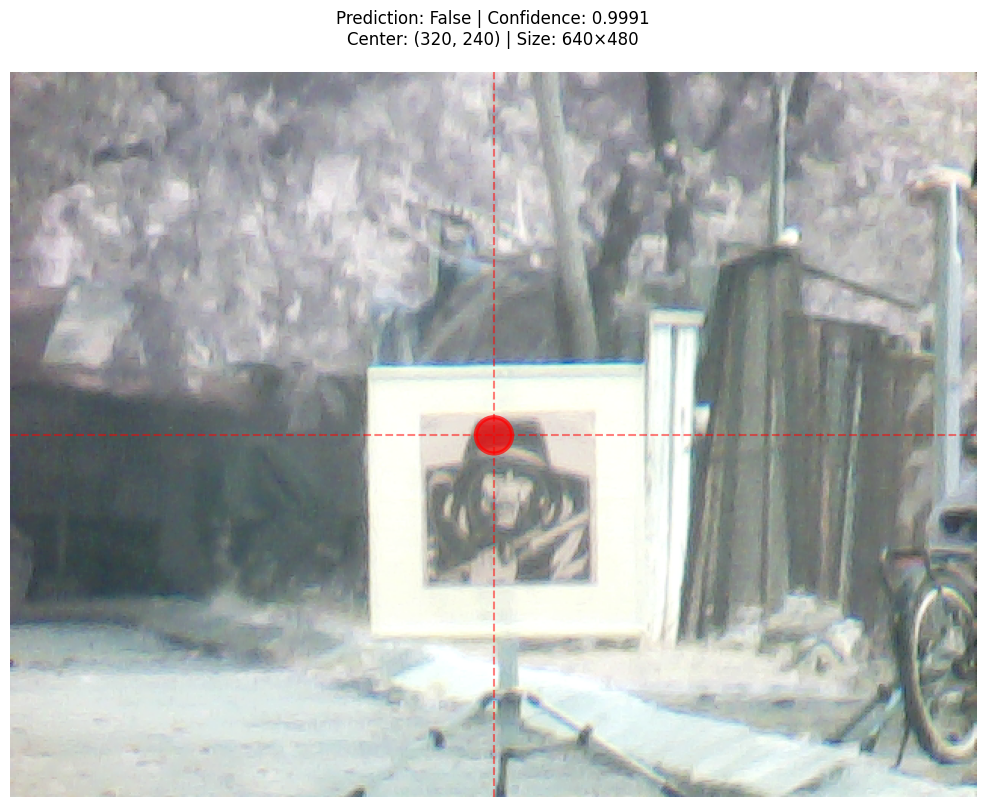

In [17]:
# Sử dụng phiên bản đơn giản
img_path = '/content/bia4 (734).bmp'
pred, confidence, center = simple_predict_with_circle(trainer, img_path, circle_radius=12)

In [18]:
# 2. Training với freezing phase (ĐÃ SỬA)
trainer.reset_for_new_training(keep_dls=True)
trainer.create_learner(arch=resnet50, pretrained=True)
trainer.train_with_discriminative_lr(
    epochs=10,
    base_lr=1e-3,
    lr_mult=10.0,
    freeze_epochs=2
)

Resetting for new training...
Learner cleaned successfully
DataLoaders preserved for new training
Created new learner: {'arch': 'resnet50', 'pretrained': True, 'created_at': datetime.datetime(2025, 9, 24, 8, 27, 37, 60005), 'reset_count': 2}
Using discriminative learning rates: slice(0.001, 0.01, None)
Phase 1: Training head only for 2 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.153315,2.462366,0.666667,0.333333,01:22
1,0.774367,0.797271,0.820513,0.179487,01:18


Phase 2: Training all layers for 8 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.630279,0.023678,1.000000,0.000000,01:41
1,0.480073,0.000002,1.000000,0.000000,01:42
2,0.537490,0.760160,0.897436,0.102564,01:41
3,0.437857,0.727415,0.794872,0.205128,01:40
4,0.369186,3.170989,0.615385,0.384615,01:40
5,0.358103,0.000000,1.000000,0.000000,01:41
6,0.324928,0.000091,1.000000,0.000000,01:40
7,0.306202,0.005711,1.000000,0.000000,01:41


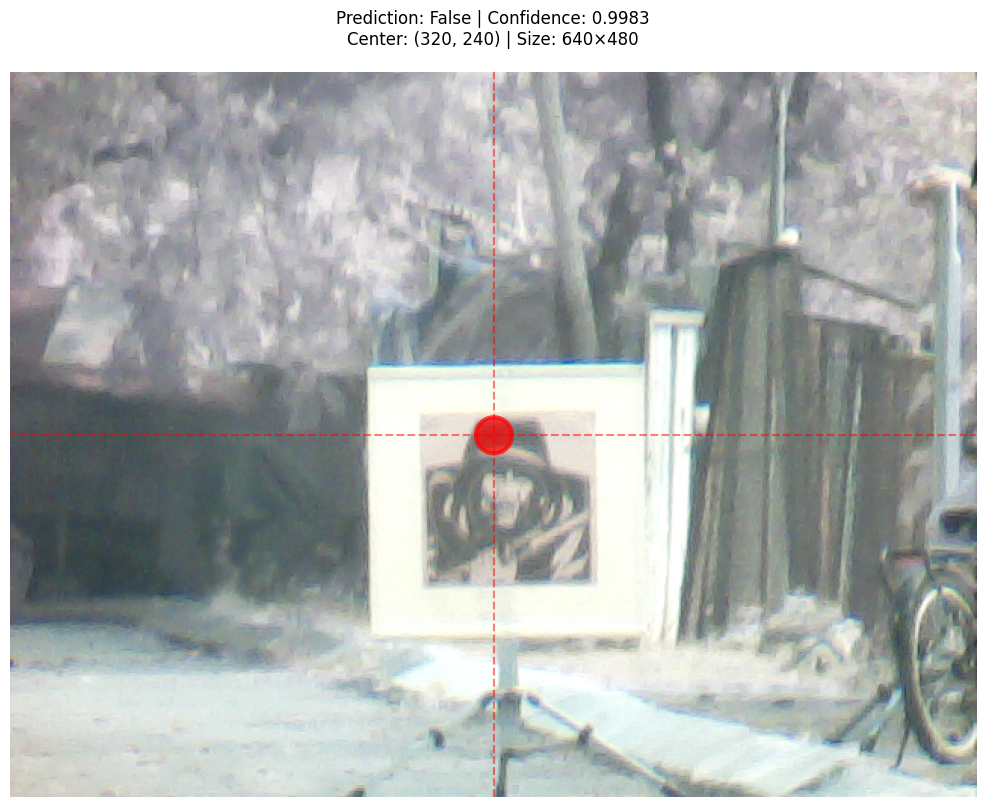

In [19]:
img_path = '/content/bia4 (734).bmp'
pred, confidence, center = simple_predict_with_circle(trainer, img_path, circle_radius=12)

In [20]:
# 3. Fine-tune approach (ĐÃ SỬA)
trainer.reset_for_new_training(keep_dls=True)
trainer.create_learner(arch=resnet50, pretrained=True)
trainer.train_fine_tune(epochs=10, base_lr=1e-3, lr_mult=10.0)

Resetting for new training...
Learner cleaned successfully
DataLoaders preserved for new training
Created new learner: {'arch': 'resnet50', 'pretrained': True, 'created_at': datetime.datetime(2025, 9, 24, 8, 50, 47, 922177), 'reset_count': 3}
Training head only for 2 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.270800,0.961564,0.846154,0.153846,01:22
1,1.099634,1.455738,0.846154,0.153846,01:14


Training all layers with discriminative LR for 8 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.005887,0.071626,0.974359,0.025641,01:45
1,0.638504,0.000150,1.000000,0.000000,01:43
2,0.575355,0.510176,0.897436,0.102564,01:43
3,0.535091,29.782408,0.512821,0.487179,01:52
4,0.465186,4.310947,0.230769,0.769231,01:47
5,0.439891,2.176272,0.358974,0.641026,01:46
6,0.400934,0.670698,0.692308,0.307692,01:44
7,0.351378,0.281410,0.897436,0.102564,01:44


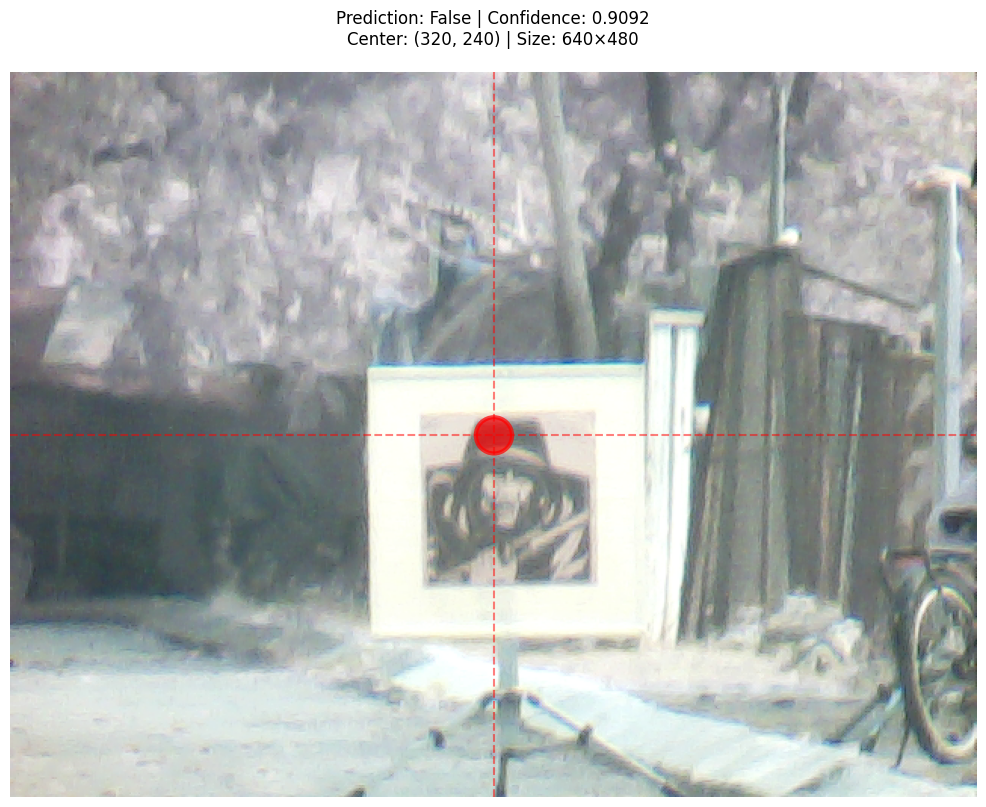

In [21]:
img_path = '/content/bia4 (734).bmp'
pred, confidence, center = simple_predict_with_circle(trainer, img_path, circle_radius=12)

In [22]:
# 4. Single learning rate (đơn giản)
trainer.reset_for_new_training(keep_dls=True)
trainer.create_learner(arch=resnet50, pretrained=True)
trainer.train_single_lr(epochs=10, lr=1e-3)

Resetting for new training...
Learner cleaned successfully
DataLoaders preserved for new training
Created new learner: {'arch': 'resnet50', 'pretrained': True, 'created_at': datetime.datetime(2025, 9, 24, 9, 8, 2, 780238), 'reset_count': 4}
Training with single LR: 0.001 for 10 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.285365,0.874281,0.615385,0.384615,01:42
1,0.971713,0.166903,0.948718,0.051282,01:42
2,0.720656,0.105847,0.974359,0.025641,01:42
3,0.572346,0.112715,0.974359,0.025641,01:42
4,0.482548,0.014520,1.000000,0.000000,01:43
5,0.424749,0.107257,0.974359,0.025641,01:42
6,0.369657,0.129972,0.923077,0.076923,01:42
7,0.314977,0.210591,0.948718,0.051282,01:42
8,0.277275,0.225785,0.948718,0.051282,01:45
9,0.254476,0.295464,0.948718,0.051282,01:43


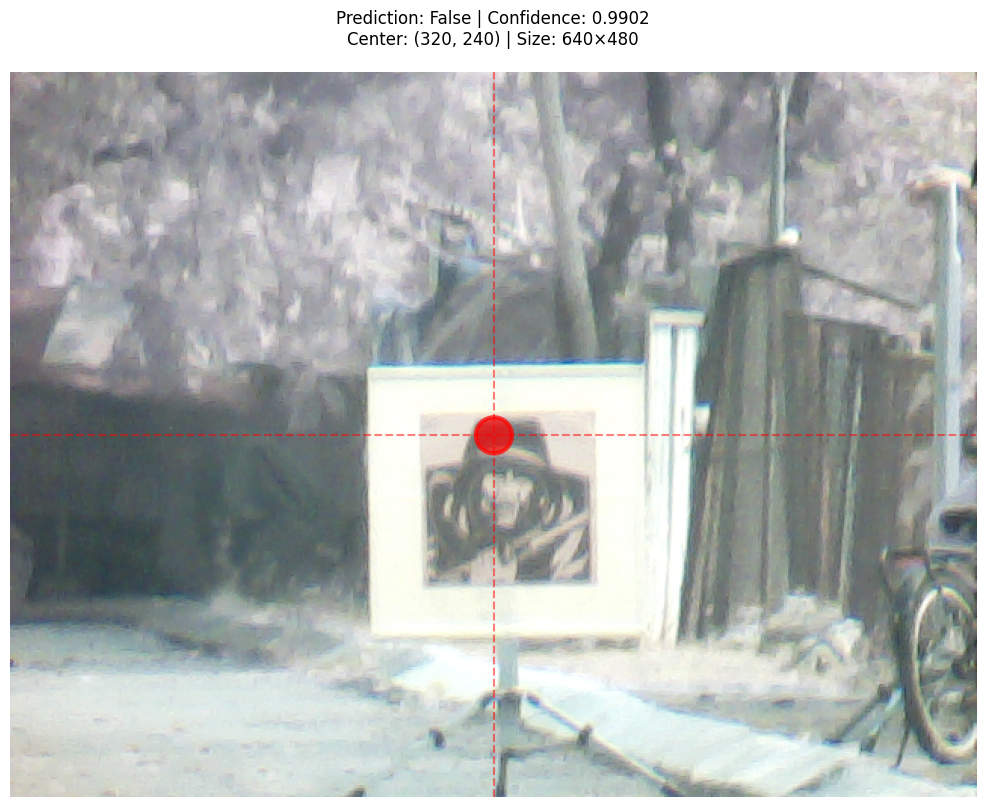

In [23]:
img_path = '/content/bia4 (734).bmp'
pred, confidence, center = simple_predict_with_circle(trainer, img_path, circle_radius=12)

Resetting for new training...
Learner cleaned successfully
DataLoaders preserved for new training
Created new learner: {'arch': 'resnet50', 'pretrained': True, 'created_at': datetime.datetime(2025, 9, 24, 9, 26, 30, 129234), 'reset_count': 5}


Suggested learning rate: 0.002511886414140463
Using discriminative learning rates: slice(0.002511886414140463, 0.02511886414140463, None)
Training all layers with discriminative LR for 10 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.153379,0.670515,0.846154,0.153846,01:43
1,1.216221,6.241526,0.615385,0.384615,01:42
2,1.155536,103.779663,0.512821,0.487179,01:42
3,0.896753,322.314026,0.512821,0.487179,01:47
4,0.716313,46.735977,0.512821,0.487179,01:45
5,0.610214,0.784826,0.846154,0.153846,01:48
6,0.519283,0.100700,0.974359,0.025641,01:46
7,0.442559,0.002505,1.000000,0.000000,01:43
8,0.400414,0.008264,1.000000,0.000000,01:46
9,0.355401,0.003582,1.000000,0.000000,01:46


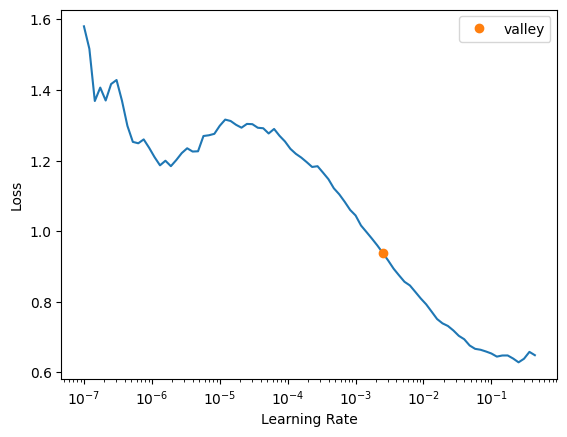

In [24]:
# 5. Training với LR tự động tìm thấy
trainer.reset_for_new_training(keep_dls=True)
trainer.create_learner(arch=resnet50, pretrained=True)
trainer.train_with_auto_lr(epochs=10)

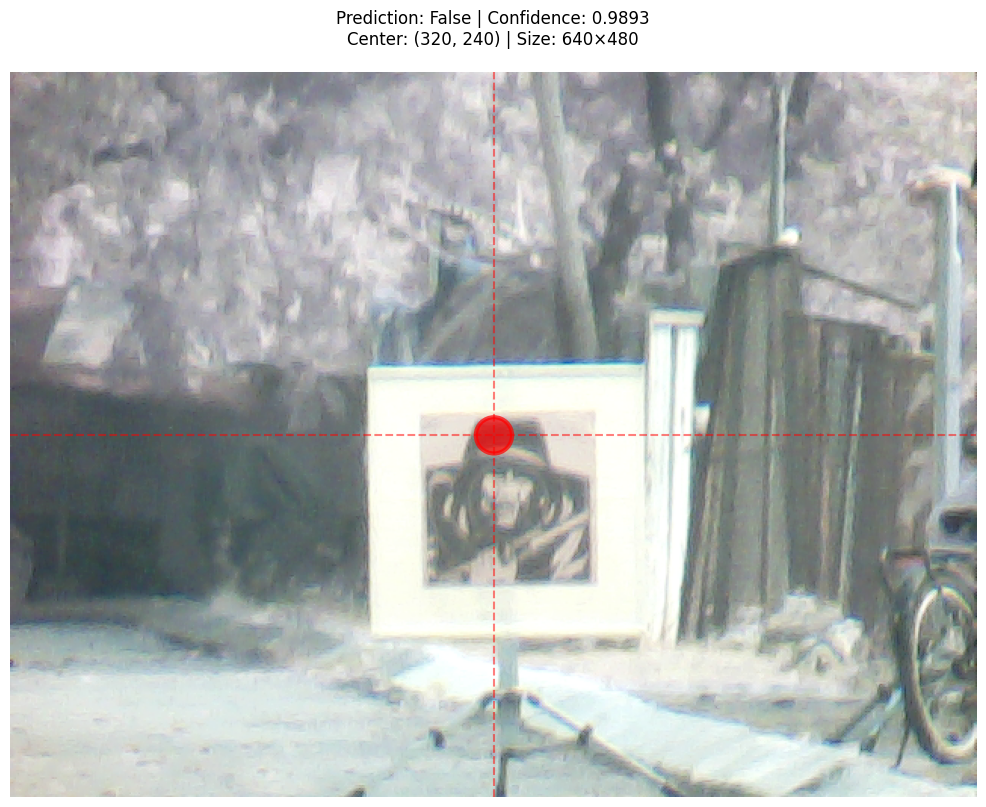

In [25]:
img_path = '/content/bia4 (734).bmp'
pred, confidence, center = simple_predict_with_circle(trainer, img_path, circle_radius=12)


=== Training Architecture 1/3: resnet18 ===
Creating new learner for comparison...
Resetting for new training...
Learner cleaned successfully
GPU cache cleared
DataLoaders preserved for new training
Created new learner: {'arch': 'resnet18', 'pretrained': True, 'created_at': datetime.datetime(2025, 9, 24, 6, 28, 45, 946613), 'reset_count': 2}


Suggested learning rate: 0.0014454397605732083
Using discriminative learning rates: slice(0.0014454397605732083, 0.014454397605732083, None)
Training all layers with discriminative LR for 5 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.329636,0.004888,1.000000,0.000000,00:01
1,1.069377,821.806519,0.487179,0.512821,00:01
2,0.862076,106.799927,0.641026,0.358974,00:01
3,0.726804,132.949387,0.512821,0.487179,00:01
4,0.595264,29.963863,0.512821,0.487179,00:01


Completed resnet18: Accuracy = 0.5128

=== Training Architecture 2/3: resnet34 ===
Creating new learner for comparison...
Resetting for new training...
Learner cleaned successfully
GPU cache cleared
DataLoaders preserved for new training
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 226MB/s]


...

Completed LR 0.0001: Accuracy = 0.6667

=== Testing Learning Rate 2/3: 0.001 ===
Creating new learner for comparison...
Resetting for new training...
Learner cleaned successfully
GPU cache cleared
DataLoaders preserved for new training
Created new learner: {'arch': 'resnet50', 'pretrained': True, 'created_at': datetime.datetime(2025, 9, 24, 6, 30, 52, 89002), 'reset_count': 6}
Training with single LR: 0.001 for 5 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.314141,0.743152,0.641026,0.358974,00:02
1,0.955769,0.231015,0.897436,0.102564,00:02
2,0.680582,0.025637,0.974359,0.025641,00:02
3,0.537170,0.000141,1.000000,0.000000,00:02
4,0.451006,0.000058,1.000000,0.000000,00:02


Completed LR 0.001: Accuracy = 1.0000

=== Testing Learning Rate 3/3: 0.01 ===
Creating new learner for comparison...
Resetting for new training...
Learner cleaned successfully
GPU cache cleared
DataLoaders preserved for new training
Created new learner: {'arch': 'resnet50', 'pretrained': True, 'created_at': datetime.datetime(2025, 9, 24, 6, 31, 5, 215324), 'reset_count': 7}
Training with single LR: 0.01 for 5 epochs


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.198641,1.699101,0.666667,0.333333,00:02
1,1.500702,46439.007812,0.487179,0.512821,00:02
2,1.305961,3347598.250000,0.512821,0.487179,00:02
3,1.313256,31030.083984,0.512821,0.487179,00:02
4,1.146031,657.141418,0.512821,0.487179,00:02


Completed LR 0.01: Accuracy = 0.5128
   learning_rate  training_time  final_accuracy  final_loss  epochs
0         0.0001      12.355240        0.666667    0.629978       5
1         0.0010      12.153367        1.000000    0.000058       5
2         0.0100      11.963922        0.512821  657.141418       5


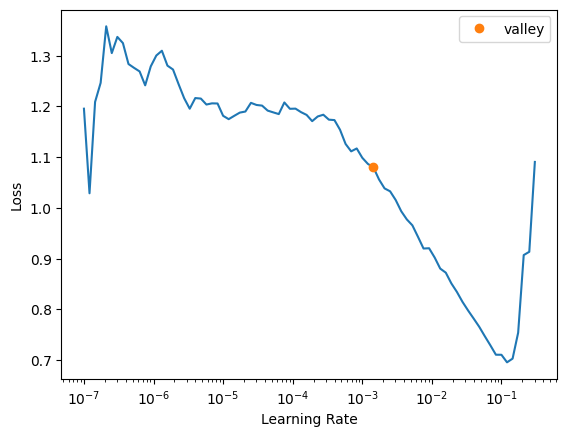

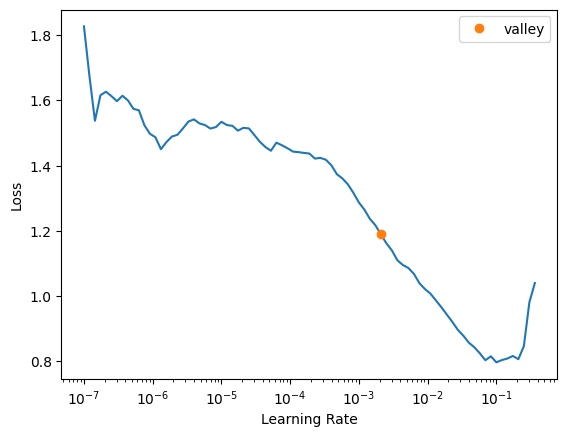

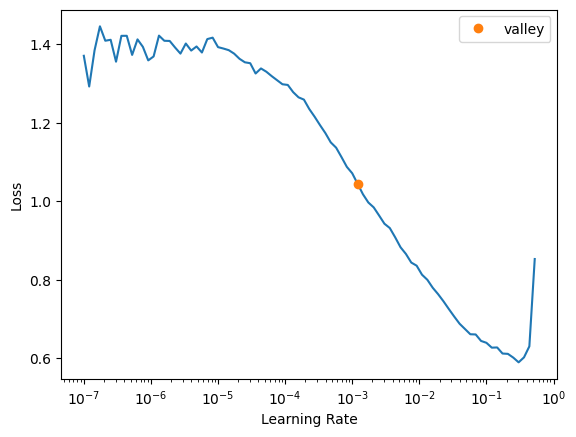

In [47]:
# So sánh architectures (ĐÃ SỬA)
architectures = [resnet18, resnet34, resnet50]
results = trainer.compare_architectures(architectures, epochs=5, df=dls)
print(results)

# So sánh learning rates
learning_rates = [1e-4, 1e-3, 1e-2]
lr_results = trainer.compare_learning_rates(learning_rates, epochs=5, df=dls)
print(lr_results)

In [60]:
# Sử dụng cho nhiều ảnh
img_paths = ['/content/bia4 (734).bmp', '/content/bia4 (715).bmp']
predict_multiple_images(trainer, img_paths)

Prediction: False, Probability: 1.0000


In [ ]:
# 5. Export/Load Model
trainer.save_model()

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


#### Try vision transformers via timm (e.g., vit_base_patch16_224). Use efficientnet_b0 or higher for efficiency. Ensemble multiple models (e.g., resnet + vit).

In [5]:
import json
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# FastAI imports
from fastai.vision.all import *
from fastai.data.transforms import RandomSplitter

# TIMM imports for Vision Transformers
import timm
from timm import create_model

class AdvancedConfig:
    """Configuration for advanced models"""
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    VALID_PCT = 0.2

    # Paths
    BASE_DIR = Path('/content').resolve()
    COCO_JSON_PATH = str(BASE_DIR / 'All-Coco-3.json')
    AUGMENTED_DIR = str(BASE_DIR / 'augmented')
    AUGMENTED_JSON_PATH = str(BASE_DIR / 'augmented' / 'augmented_coco.json')
    MERGED_JSON_PATH = str(BASE_DIR / 'All-Coco-3-merged.json')
    MODEL_SAVE_PATH = str(BASE_DIR / 'models' / 'bia4_inside_model.pkl')

    # Category ID for Bia4_Inside
    BIA4_INSIDE_CATEGORY_ID = 3

    # Model architectures
    ARCHITECTURES = {
        'resnet50': resnet50,
        'resnet101': resnet101,
        'efficientnet_b0': 'efficientnet_b0',
        'efficientnet_b3': 'efficientnet_b3',
        'vit_base_patch16_224': 'vit_base_patch16_224',
        'vit_small_patch16_224': 'vit_small_patch16_224',
        'swin_base_patch4_window7_224': 'swin_base_patch4_window7_224',
        'convnext_base': 'convnext_base'
    }

    # Training configurations
    EPOCHS_STAGE1 = 5
    EPOCHS_STAGE2 = 10

    # Ensemble settings
    ENSEMBLE_MODELS_DIR = str(BASE_DIR / 'ensemble_models')
    ENSEMBLE_PREDICTIONS_PATH = str(BASE_DIR / 'ensemble_predictions.pkl')

class TimmModelWrapper:
    """Wrapper for TIMM models to work with FastAI"""
    def __init__(self, model_name: str, num_classes: int = 2, pretrained: bool = True):
        self.model_name = model_name
        self.num_classes = num_classes
        self.pretrained = pretrained

    def __call__(self):
        """Create and return the TIMM model"""
        model = create_model(
            self.model_name,
            pretrained=self.pretrained,
            num_classes=self.num_classes
        )
        return model

class AdvancedModelTrainer:
    """Trainer with support for multiple architectures and ensemble methods"""
    def __init__(self, config: AdvancedConfig):
        self.config = config
        self.models = {}
        self.predictions = {}
        self.validation_results = {}

    def create_advanced_data_loaders(self, df: pd.DataFrame) -> DataLoaders:
        """Create DataLoaders with basic augmentation"""
        batch_tfms = [
            *aug_transforms(
                mult=2.0,
                max_rotate=20,
                max_zoom=1.2,
                max_warp=0.15,
                max_lighting=0.4,
                p_affine=0.8,
                p_lighting=0.8
            )
        ]

        dblock = DataBlock(
            blocks=(ImageBlock, CategoryBlock),
            get_x=ColReader('image_path'),
            get_y=ColReader('label'),
            splitter=RandomSplitter(valid_pct=self.config.VALID_PCT, seed=self.config.SEED),
            item_tfms=[Resize(self.config.IMG_SIZE)],
            batch_tfms=batch_tfms
        )

        dls = dblock.dataloaders(df, bs=self.config.BATCH_SIZE)
        return dls

    def train_single_model(self, arch_name: str, dls: DataLoaders, save_model: bool = True) -> Tuple[Learner, Dict]:
        """Train a single model architecture"""
        print(f"\n=== Training {arch_name} ===")

        # Create learner based on architecture type
        if arch_name in ['resnet50', 'resnet101']:
            arch = self.config.ARCHITECTURES[arch_name]
            learn = vision_learner(
                dls,
                arch,
                pretrained=True,
                metrics=[accuracy, error_rate, F1Score()]
            )
        else:
            model_wrapper = TimmModelWrapper(
                self.config.ARCHITECTURES[arch_name],
                num_classes=len(dls.vocab)
            )
            learn = Learner(
                dls,
                model_wrapper(),
                metrics=[accuracy, error_rate, F1Score()]
            )

        # Find optimal learning rate
        print("Finding optimal learning rate...")
        with learn.no_bar():
            lr_min = learn.lr_find(show_plot=False)

        optimal_lr = lr_min.valley if hasattr(lr_min, 'valley') else 1e-3
        print(f"Optimal LR: {optimal_lr:.2e}")

        # Training with progressive resizing
        print("Stage 1: Initial training...")
        with learn.no_bar():
            if arch_name.startswith('vit') or arch_name.startswith('swin'):
                learn.freeze()
                learn.fit_one_cycle(
                    self.config.EPOCHS_STAGE1,
                    slice(optimal_lr/10, optimal_lr)
                )
                learn.unfreeze()
                learn.fit_one_cycle(
                    self.config.EPOCHS_STAGE2,
                    slice(optimal_lr/100, optimal_lr/10)
                )
            else:
                learn.fine_tune(
                    self.config.EPOCHS_STAGE1 + self.config.EPOCHS_STAGE2,
                    base_lr=optimal_lr
                )

        # Evaluate model
        results = self._evaluate_model(learn, arch_name)

        # Save model
        if save_model:
            model_path = Path(self.config.ENSEMBLE_MODELS_DIR) / f"{arch_name}_model.pkl"
            model_path.parent.mkdir(parents=True, exist_ok=True)
            learn.export(model_path)
            print(f"Model saved: {model_path}")

        self.models[arch_name] = learn
        self.validation_results[arch_name] = results

        return learn, results

    def _evaluate_model(self, learn: Learner, model_name: str) -> Dict:
        """Evaluate model"""
        val_dl = learn.dls.valid
        preds, targets = learn.get_preds(dl=val_dl)

        y_pred = preds.argmax(dim=1).numpy()
        y_true = targets.numpy()
        y_prob = preds.numpy()

        accuracy = (y_pred == y_true).mean()
        class_report = classification_report(
            y_true, y_pred,
            target_names=['Not_Bia4_Inside', 'Bia4_Inside'],
            output_dict=True
        )

        results = {
            'accuracy': accuracy,
            'predictions': y_pred,
            'probabilities': y_prob,
            'targets': y_true,
            'classification_report': class_report,
            'confusion_matrix': confusion_matrix(y_true, y_pred)
        }

        print(f"\n{model_name} Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-Score: {class_report['weighted avg']['f1-score']:.4f}")

        return results

    def train_multiple_models(self, df: pd.DataFrame, architectures: List[str] = None) -> Dict:
        """Train multiple model architectures"""
        if architectures is None:
            architectures = ['resnet50', 'efficientnet_b0', 'vit_base_patch16_224']

        print(f"Training {len(architectures)} models...")
        results = {}

        for arch_name in architectures:
            try:
                dls = self.create_advanced_data_loaders(df)
                learn, model_results = self.train_single_model(arch_name, dls)
                results[arch_name] = model_results

                self.predictions[arch_name] = {
                    'probabilities': model_results['probabilities'],
                    'predictions': model_results['predictions'],
                    'targets': model_results['targets']
                }

                del learn
                torch.cuda.empty_cache() if torch.cuda.is_available() else None

            except Exception as e:
                print(f"Error training {arch_name}: {e}")
                continue

        self._save_ensemble_data()
        return results

    def _save_ensemble_data(self):
        """Save predictions for ensemble methods"""
        ensemble_data = {
            'predictions': self.predictions,
            'validation_results': self.validation_results,
            'config': {
                'architectures': list(self.predictions.keys()),
                'img_size': self.config.IMG_SIZE,
                'batch_size': self.config.BATCH_SIZE
            }
        }

        with open(self.config.ENSEMBLE_PREDICTIONS_PATH, 'wb') as f:
            pickle.dump(ensemble_data, f)

        print(f"Ensemble data saved: {self.config.ENSEMBLE_PREDICTIONS_PATH}")

class EnsembleMethod:
    """Ensemble methods for combining multiple models"""
    def __init__(self, config: AdvancedConfig):
        self.config = config
        self.ensemble_data = None

    def load_ensemble_data(self) -> Dict:
        """Load saved ensemble predictions"""
        with open(self.config.ENSEMBLE_PREDICTIONS_PATH, 'rb') as f:
            self.ensemble_data = pickle.load(f)
        return self.ensemble_data

    def simple_average_ensemble(self) -> Tuple[np.ndarray, float]:
        """Simple averaging ensemble"""
        if self.ensemble_data is None:
            self.load_ensemble_data()

        predictions = self.ensemble_data['predictions']
        all_probs = []
        targets = None

        for model_name, pred_data in predictions.items():
            all_probs.append(pred_data['probabilities'])
            if targets is None:
                targets = pred_data['targets']

        ensemble_probs = np.mean(all_probs, axis=0)
        ensemble_preds = ensemble_probs.argmax(axis=1)
        accuracy = (ensemble_preds == targets).mean()

        print(f"Simple Average Ensemble Accuracy: {accuracy:.4f}")
        return ensemble_preds, accuracy

    def weighted_ensemble(self, weights: Optional[List[float]] = None) -> Tuple[np.ndarray, float]:
        """Weighted ensemble based on model performance"""
        if self.ensemble_data is None:
            self.load_ensemble_data()

        predictions = self.ensemble_data['predictions']
        val_results = self.ensemble_data['validation_results']

        if weights is None:
            weights = [val_results[model_name]['accuracy'] for model_name in predictions.keys()]
            weights = np.array(weights) / np.sum(weights)

        print(f"Model weights: {dict(zip(predictions.keys(), weights))}")

        all_probs = []
        targets = None

        for i, (model_name, pred_data) in enumerate(predictions.items()):
            weighted_probs = pred_data['probabilities'] * weights[i]
            all_probs.append(weighted_probs)
            if targets is None:
                targets = pred_data['targets']

        ensemble_probs = np.sum(all_probs, axis=0)
        ensemble_preds = ensemble_probs.argmax(axis=1)
        accuracy = (ensemble_preds == targets).mean()
        print(f"Weighted Ensemble Accuracy: {accuracy:.4f}")
        return ensemble_preds, accuracy

    def voting_ensemble(self, voting_type: str = 'soft') -> Tuple[np.ndarray, float]:
        """Voting ensemble (hard or soft)"""
        if self.ensemble_data is None:
            self.load_ensemble_data()

        predictions = self.ensemble_data['predictions']

        if voting_type == 'hard':
            all_preds = []
            targets = None
            for model_name, pred_data in predictions.items():
                all_preds.append(pred_data['predictions'])
                if targets is None:
                    targets = pred_data['targets']

            votes = np.array(all_preds).T
            ensemble_preds = np.array([1 if np.sum(sample_votes) > len(sample_votes) / 2 else 0 for sample_votes in votes])
        else:
            ensemble_preds, _ = self.simple_average_ensemble()
            targets = list(predictions.values())[0]['targets']

        accuracy = (ensemble_preds == targets).mean()
        print(f"{voting_type.title()} Voting Ensemble Accuracy: {accuracy:.4f}")
        return ensemble_preds, accuracy

class ModelAnalyzer:
    """Analysis and visualization for trained models"""
    def __init__(self, config: AdvancedConfig):
        self.config = config

    def compare_models(self, validation_results: Dict) -> pd.DataFrame:
        """Compare performance across models"""
        comparison_data = []
        for model_name, results in validation_results.items():
            class_report = results['classification_report']
            comparison_data.append({
                'Model': model_name,
                'Accuracy': results['accuracy'],
                'F1_Score': class_report['weighted avg']['f1-score'],
                'Precision': class_report['weighted avg']['precision'],
                'Recall': class_report['weighted avg']['recall'],
                'Bia4_Inside_F1': class_report.get('1', {}).get('f1-score', 0),
                'Not_Bia4_Inside_F1': class_report.get('0', {}).get('f1-score', 0)
            })

        df_comparison = pd.DataFrame(comparison_data)
        if len(df_comparison) > 0 and 'Accuracy' in df_comparison.columns:
            df_comparison = df_comparison.sort_values('Accuracy', ascending=False)

        print("=== Model Performance Comparison ===")
        if len(df_comparison) > 0:
            print(df_comparison.round(4).to_string(index=False))
        else:
            print("No validation results available.")
        return df_comparison

    def plot_model_comparison(self, df_comparison: pd.DataFrame):
        """Visualize model comparison"""
        if len(df_comparison) == 0:
            print("No data to plot.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        if 'Accuracy' in df_comparison.columns:
            axes[0, 0].bar(df_comparison['Model'], df_comparison['Accuracy'])
            axes[0, 0].set_title('Model Accuracy Comparison')
            axes[0, 0].set_ylabel('Accuracy')
            axes[0, 0].tick_params(axis='x', rotation=45)

        if 'F1_Score' in df_comparison.columns:
            axes[0, 1].bar(df_comparison['Model'], df_comparison['F1_Score'])
            axes[0, 1].set_title('F1 Score Comparison')
            axes[0, 1].set_ylabel('F1 Score')
            axes[0, 1].tick_params(axis='x', rotation=45)

        if 'Bia4_Inside_F1' in df_comparison.columns and 'Not_Bia4_Inside_F1' in df_comparison.columns:
            x = np.arange(len(df_comparison))
            width = 0.35
            axes[1, 0].bar(x - width/2, df_comparison['Bia4_Inside_F1'], width, label='Bia4_Inside', alpha=0.7)
            axes[1, 0].bar(x + width/2, df_comparison['Not_Bia4_Inside_F1'], width, label='Not_Bia4_Inside', alpha=0.7)
            axes[1, 0].set_title('Class-specific F1 Scores')
            axes[1, 0].set_ylabel('F1 Score')
            axes[1, 0].set_xticks(x)
            axes[1, 0].set_xticklabels(df_comparison['Model'], rotation=45)
            axes[1, 0].legend()

        if 'Precision' in df_comparison.columns and 'Recall' in df_comparison.columns:
            axes[1, 1].scatter(df_comparison['Precision'], df_comparison['Recall'])
            for i, model in enumerate(df_comparison['Model']):
                axes[1, 1].annotate(model, (df_comparison['Precision'].iloc[i], df_comparison['Recall'].iloc[i]))
            axes[1, 1].set_title('Precision vs Recall')
            axes[1, 1].set_xlabel('Precision')
            axes[1, 1].set_ylabel('Recall')

        plt.tight_layout()
        plt.show()

    def plot_confusion_matrices(self, validation_results: Dict):
        """Plot confusion matrices for all models"""
        n_models = len(validation_results)
        cols = min(3, n_models)
        rows = (n_models + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
        if n_models == 1:
            axes = [axes]
        elif rows == 1:
            axes = axes.reshape(1, -1)

        for idx, (model_name, results) in enumerate(validation_results.items()):
            row = idx // cols
            col = idx % cols
            ax = axes[row, col] if rows > 1 else axes[col]

            cm = results['confusion_matrix']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                       xticklabels=['Not_Bia4_Inside', 'Bia4_Inside'],
                       yticklabels=['Not_Bia4_Inside', 'Bia4_Inside'])
            ax.set_title(f'{model_name} Confusion Matrix')
            ax.set_ylabel('True Label')
            ax.set_xlabel('Predicted Label')

        for idx in range(n_models, rows * cols):
            row = idx // cols
            col = idx % cols
            if rows > 1:
                axes[row, col].set_visible(False)
            else:
                axes[col].set_visible(False)

        plt.tight_layout()
        plt.show()

class AdvancedBia4Pipeline:
    """Complete pipeline for advanced BIA4 classification"""
    def __init__(self, config: AdvancedConfig = None):
        self.config = config or AdvancedConfig()
        self.processor = CocoDataProcessor(self.config)
        self.trainer = AdvancedModelTrainer(self.config)
        self.ensemble = EnsembleMethod(self.config)
        self.analyzer = ModelAnalyzer(self.config)

    def run_complete_pipeline(self, df: pd.DataFrame, architectures: List[str] = None, use_ensemble: bool = True):
        """Run complete training pipeline"""
        print("=== Starting Advanced BIA4 Classification Pipeline ===")

        set_random_seeds(self.config.SEED)

        if architectures is None:
            architectures = ['resnet50', 'efficientnet_b0', 'vit_base_patch16_224']

        print("\n1. Training multiple architectures...")
        validation_results = self.trainer.train_multiple_models(df, architectures)

        if not validation_results:
            print("No models were trained successfully!")
            return {'individual_results': {}, 'comparison_df': pd.DataFrame(), 'ensemble_results': None}

        print("\n2. Comparing individual model performance...")
        df_comparison = self.analyzer.compare_models(validation_results)
        self.analyzer.plot_model_comparison(df_comparison)
        self.analyzer.plot_confusion_matrices(validation_results)

        ensemble_results = None
        if use_ensemble and len(validation_results) > 1:
            print("\n3. Creating ensemble models...")
            try:
                avg_preds, avg_acc = self.ensemble.simple_average_ensemble()
                weighted_preds, weighted_acc = self.ensemble.weighted_ensemble()
                soft_preds, soft_acc = self.ensemble.voting_ensemble('soft')
                hard_preds, hard_acc = self.ensemble.voting_ensemble('hard')

                print(f"\n=== Ensemble Results Summary ===")
                print(f"Simple Average: {avg_acc:.4f}")
                print(f"Weighted Average: {weighted_acc:.4f}")
                print(f"Soft Voting: {soft_acc:.4f}")
                print(f"Hard Voting: {hard_acc:.4f}")

                ensemble_results = {
                    'simple_average': avg_acc,
                    'weighted_average': weighted_acc,
                    'soft_voting': soft_acc,
                    'hard_voting': hard_acc
                }
            except Exception as e:
                print(f"Error in ensemble methods: {e}")
                print("Skipping ensemble evaluation...")

        if validation_results:
            best_individual = max(validation_results.items(), key=lambda x: x[1]['accuracy'])
            print(f"Best Individual Model: {best_individual[0]} ({best_individual[1]['accuracy']:.4f})")

        return {
            'individual_results': validation_results,
            'comparison_df': df_comparison,
            'ensemble_results': ensemble_results
        }

In [6]:
# 1. Khởi tạo pipeline
config = AdvancedConfig()
set_random_seeds(config.SEED)

pipeline = AdvancedBia4Pipeline(config)
processor = CocoDataProcessor(config)
dataset_builder = Bia4DatasetBuilder(processor)
augmenter = Bia4Augmenter(processor)
analyzer = DatasetAnalyzer(processor, display_mode='notebook')
trainer = Bia4ModelTrainer(config)

print("Loading COCO data...")
coco_data = processor.load_coco_data(config.COCO_JSON_PATH, config.BASE_DIR)

print("Creating base dataset...")
df_base = dataset_builder.create_label_dataframe(coco_data)

print("Handling augmented dataset...")
aug_json_path = Path(config.AUGMENTED_JSON_PATH)
if aug_json_path.exists():
    print("Loading existing augmented data...")
    aug_data = processor.load_coco_data(str(aug_json_path), base_image_dir=str(config.AUGMENTED_DIR))
    df_aug = dataset_builder.create_label_dataframe(aug_data)
    aug_json = aug_data
else:
    print("Performing data augmentation...")
    df_aug, aug_json = augmenter.augment_dataset(coco_data)
    processor.save_coco_data(aug_json, config.AUGMENTED_JSON_PATH)

merged_coco = coco_data.copy()
merged_coco['images'].extend(aug_json['images'])
merged_coco['annotations'].extend(aug_json['annotations'])
processor.save_coco_data(merged_coco, config.MERGED_JSON_PATH)

df_combined = pd.concat([df_base, df_aug], ignore_index=True)
print(f"Combined dataset size: {len(df_combined)}")




Loading COCO data...
Creating base dataset...
Handling augmented dataset...
Loading existing augmented data...
Combined dataset size: 197


In [7]:
# 2. Chạy với các architectures bạn muốn test
results = pipeline.run_complete_pipeline(
    df_combined,  # DataFrame của bạn
    architectures=[
        'resnet50',
        'efficientnet_b0',
        'vit_base_patch16_224'
    ],
    use_ensemble=False
)

=== Starting Advanced BIA4 Classification Pipeline ===

1. Training multiple architectures...
Training 3 models...

=== Training resnet50 ===
Finding optimal learning rate...
Optimal LR: 7.59e-03
Stage 1: Initial training...
[0, 1.5099506378173828, 0.2907242774963379, 0.8461538553237915, 0.1538461595773697, 0.0, '01:17']
[0, 1.4400155544281006, 1.9339748620986938, 0.1794871836900711, 0.8205128312110901, 0.0, '01:44']
[1, 1.360950231552124, 1.4041215181350708, 0.1538461595773697, 0.8461538553237915, 0.0, '01:41']
[2, 1.322218894958496, 0.8845919966697693, 0.5641025900840759, 0.43589743971824646, 0.0, '01:41']
[3, 1.2175055742263794, 0.8622854351997375, 0.5641025900840759, 0.43589743971824646, 0.0, '01:40']
[4, 1.1321145296096802, 0.6214210987091064, 0.6666666865348816, 0.3333333432674408, 0.0, '01:43']
[5, 1.061911702156067, 0.912998616695404, 0.5641025900840759, 0.43589743971824646, 0.0, '01:45']
[6, 0.9854934215545654, 1.1226645708084106, 0.5897436141967773, 0.41025641560554504, 0.0, 

KeyboardInterrupt: 

In [ ]:
# 3. Hoặc train từng model riêng lẻ
trainer = AdvancedModelTrainer(config)
dls, callbacks = trainer.create_advanced_data_loaders(df_combined)
learn, results = trainer.train_single_model('vit_base_patch16_224', dls, callbacks)

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from fastai.vision.all import *
from pathlib import Path

config = AdvancedConfig()  # Từ code trước
architectures = ['resnet50', 'efficientnet_b0', 'vit_base_patch16_224']
image_path = '/content/bia4 (715).bmp'  # Thay bằng ảnh thực

results = {}
for arch in architectures:
    model_path = Path(config.ENSEMBLE_MODELS_DIR) / f"{arch}_model.pkl"
    if model_path.exists():
        learn = load_learner(model_path)
        pred, pred_idx, probs = learn.predict(image_path)
        results[arch] = 'Bia4_Inside' if pred_idx.item() == 1 else 'Not_Bia4_Inside'

img = Image.open(image_path)
center = (img.width / 2, img.height / 2)

plt.imshow(img)
plt.scatter(*center, c='r', marker='x')
plt.show()

print(results, center)

#### Tune batch size (e.g., 32-128) and weight decay (1e-4 to 1e-2)

## Segmentation